In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("dailyActivity_merged.csv")
print(df.head())        # First 5 rows
print(df.shape)         # Rows × Columns
print(df.info())        # Column types
print(df.describe())

           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.71                      0.41   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0                 6.06

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Convert date column to proper datetime
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])

# Remove duplicates
df = df.drop_duplicates()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64


In [ ]:
# Average steps per user
avg_steps = df.groupby('Id')['TotalSteps'].mean()
print(avg_steps)

# Correlation between steps and calories
print(df[['TotalSteps', 'Calories']].corr())

Id
1503960366    12116.741935
1624580081     5743.903226
1644430081     7282.966667
1844505072     2580.064516
1927972279      916.129032
2022484408    11370.645161
2026352035     5566.870968
2320127002     4716.870968
2347167796     9519.666667
2873212765     7555.774194
3372868164     6861.650000
3977333714    10984.566667
4020332650     2267.225806
4057192912     3838.000000
4319703577     7268.838710
4388161847    10813.935484
4445114986     4796.548387
4558609924     7685.129032
4702921684     8572.064516
5553957443     8612.580645
5577150313     8304.433333
6117666160     7046.714286
6290855005     5649.551724
6775888955     2519.692308
6962181067     9794.806452
7007744171    11323.423077
7086361926     9371.774194
8053475328    14763.290323
8253242879     6482.157895
8378563200     8717.709677
8583815059     7198.516129
8792009665     1853.724138
8877689391    16040.032258
Name: TotalSteps, dtype: float64
            TotalSteps  Calories
TotalSteps    1.000000  0.591568
Calorie

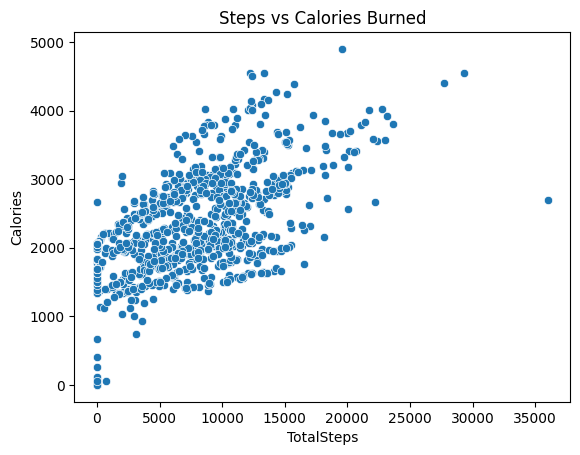

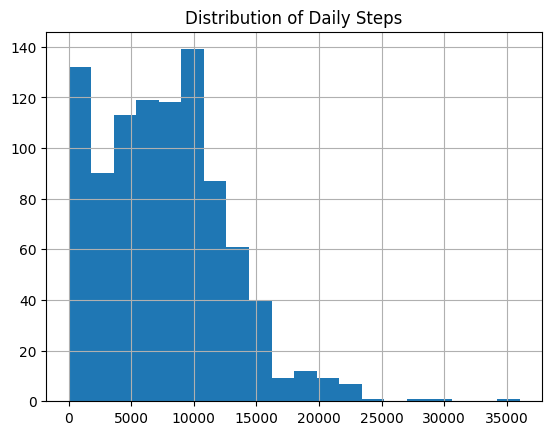

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Steps vs Calories scatter plot
sns.scatterplot(data=df, x='TotalSteps', y='Calories')
plt.title("Steps vs Calories Burned")
plt.show()

# Distribution of daily steps
df['TotalSteps'].hist(bins=20)
plt.title("Distribution of Daily Steps")
plt.show()

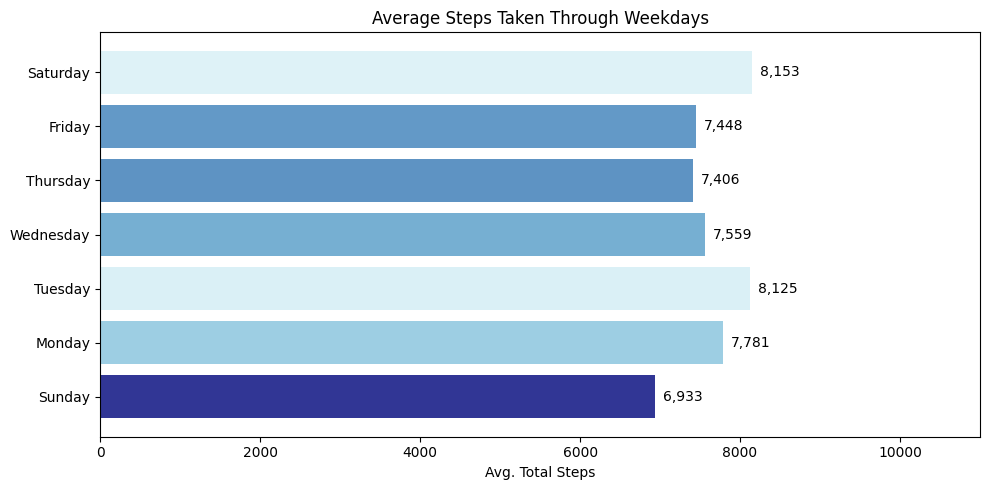

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = pd.read_csv("dailyActivity_merged.csv")
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

# Order days
day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
avg_steps = df.groupby('Weekday')['TotalSteps'].mean().reindex(day_order)

# Color map based on value (higher = more orange/red)
norm = mcolors.Normalize(vmin=avg_steps.min(), vmax=10000)
colors = plt.cm.RdYlBu_r(norm(avg_steps.values))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(day_order, avg_steps.values, color=colors)

for bar, val in zip(bars, avg_steps.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center')

ax.set_xlabel('Avg. Total Steps')
ax.set_title('Average Steps Taken Through Weekdays')
ax.set_xlim(0, 11000)
plt.tight_layout()
plt.savefig('avg_steps_weekday.png', dpi=150)
plt.show()

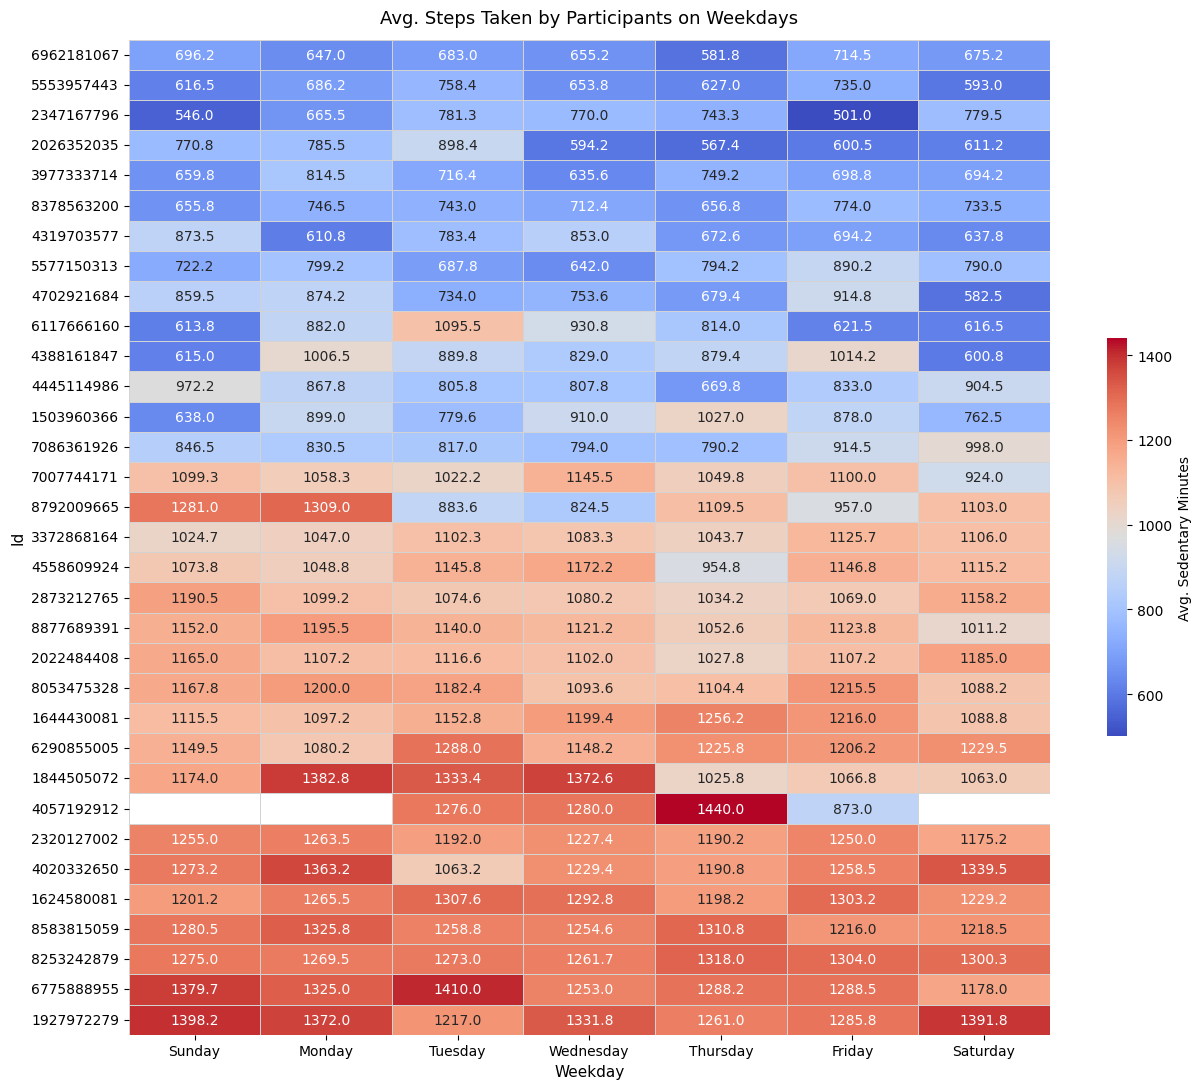

In [ ]:
# ── STEP 1: Imports ───────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── STEP 2: Load Data ─────────────────────────────────
df = pd.read_csv("dailyActivity_merged.csv")
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

# ── STEP 3: Prepare Pivot ─────────────────────────────
pivot_sed = df.pivot_table(index='Id',
                            columns='Weekday',
                            values='SedentaryMinutes',
                            aggfunc='mean')

pivot_sed = pivot_sed[day_order]
pivot_sed.columns.name = 'Weekday'

pivot_sed['Grand Total'] = pivot_sed.mean(axis=1)
pivot_sed = pivot_sed.sort_values('Grand Total')
pivot_sed = pivot_sed.drop(columns='Grand Total')

pivot_sed = pivot_sed.round(1)

# ── STEP 4: Plot Heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(pivot_sed,
            cmap='coolwarm',
            annot=True,
            fmt='.1f',
            linewidths=0.4,
            linecolor='lightgray',
            cbar_kws={'label': 'Avg. Sedentary Minutes',
                      'orientation': 'vertical',
                      'shrink': 0.4},
            ax=ax)

ax.set_title('Avg. Steps Taken by Participants on Weekdays',
             fontsize=13, pad=12)
ax.set_xlabel('Weekday', fontsize=11)
ax.set_ylabel('Id', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7035/1655411629.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


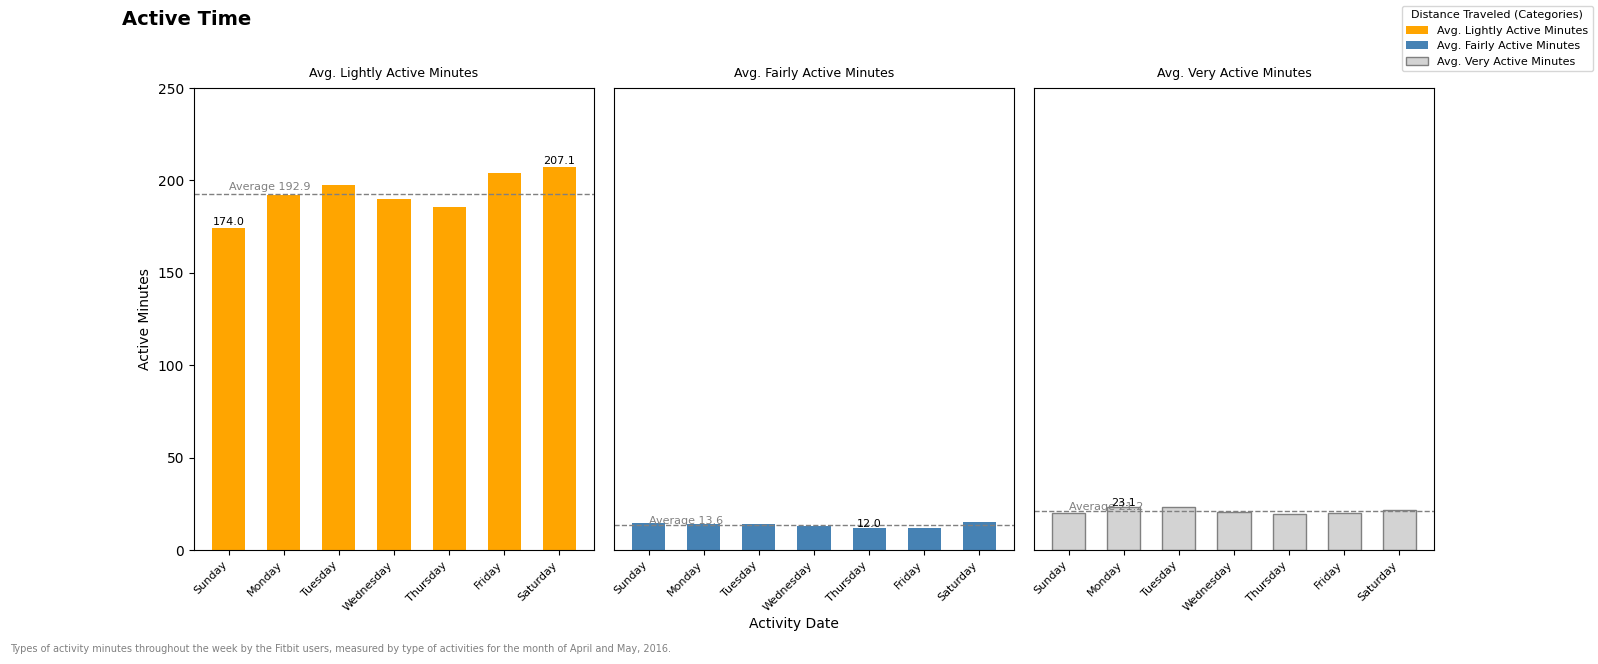

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── STEP 1: Load & Prepare ────────────────────────────
df = pd.read_csv("dailyActivity_merged.csv")
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

# Average each activity type per weekday
weekly = df.groupby('Weekday').agg(
    Lightly=('LightlyActiveMinutes', 'mean'),
    Fairly=('FairlyActiveMinutes',   'mean'),
    Very=('VeryActiveMinutes',       'mean')
).reindex(day_order).round(1)

# Overall averages (horizontal reference lines)
avg_lightly = weekly['Lightly'].mean()
avg_fairly  = weekly['Fairly'].mean()
avg_very    = weekly['Very'].mean()

# ── STEP 2: Plot 3 Panels ─────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6),
                                     sharey=False,
                                     gridspec_kw={'wspace': 0.05})

x = range(len(day_order))

# --- Panel 1: Lightly Active (Orange) ---
ax1.bar(x, weekly['Lightly'], color='orange', width=0.6)
ax1.axhline(avg_lightly, color='gray', linestyle='--', linewidth=1)
ax1.text(0, avg_lightly + 2, f'Average {avg_lightly:.1f}', fontsize=8, color='gray')

# Add value labels on first and last bar
ax1.text(0,    weekly['Lightly'].iloc[0] + 2, f"{weekly['Lightly'].iloc[0]:.1f}", ha='center', fontsize=8)
ax1.text(6,    weekly['Lightly'].iloc[6] + 2, f"{weekly['Lightly'].iloc[6]:.1f}", ha='center', fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(day_order, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Active Minutes', fontsize=10)
ax1.set_title('Avg. Lightly Active Minutes', fontsize=9, pad=8)
ax1.set_ylim(0, 250)

# --- Panel 2: Fairly Active (Blue) ---
ax2.bar(x, weekly['Fairly'], color='steelblue', width=0.6)
ax2.axhline(avg_fairly, color='gray', linestyle='--', linewidth=1)
ax2.text(0, avg_fairly + 0.5, f'Average {avg_fairly:.1f}', fontsize=8, color='gray')

ax2.set_xticks(x)
ax2.set_xticklabels(day_order, rotation=45, ha='right', fontsize=8)
ax2.set_title('Avg. Fairly Active Minutes', fontsize=9, pad=8)
ax2.set_yticks([])   # hide y-axis for middle panel
ax2.set_ylim(0, 250)

# Add min value label
min_idx = weekly['Fairly'].idxmin()
min_pos = day_order.index(min_idx)
ax2.text(min_pos, weekly['Fairly'].min() + 0.5,
         f"{weekly['Fairly'].min():.1f}", ha='center', fontsize=8)

# --- Panel 3: Very Active (Gray) ---
ax3.bar(x, weekly['Very'], color='lightgray', width=0.6, edgecolor='gray')
ax3.axhline(avg_very, color='gray', linestyle='--', linewidth=1)
ax3.text(0, avg_very + 0.5, f'Average {avg_very:.1f}', fontsize=8, color='gray')

# Add max value label
max_idx = weekly['Very'].idxmax()
max_pos = day_order.index(max_idx)
ax3.text(max_pos, weekly['Very'].max() + 0.5,
         f"{weekly['Very'].max():.1f}", ha='center', fontsize=8)

ax3.set_xticks(x)
ax3.set_xticklabels(day_order, rotation=45, ha='right', fontsize=8)
ax3.set_title('Avg. Very Active Minutes', fontsize=9, pad=8)
ax3.set_yticks([])   # hide y-axis for right panel
ax3.set_ylim(0, 250)

# ── STEP 3: Overall Formatting ────────────────────────
fig.suptitle('Active Time', fontsize=14, x=0.08, y=1.01, ha='left', fontweight='bold')

# Shared x-axis label
fig.text(0.5, -0.02, 'Activity Date', ha='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='orange',    label='Avg. Lightly Active Minutes'),
                   Patch(facecolor='steelblue', label='Avg. Fairly Active Minutes'),
                   Patch(facecolor='lightgray', edgecolor='gray', label='Avg. Very Active Minutes')]
fig.legend(handles=legend_elements, loc='upper right',
           title='Distance Traveled (Categories)', fontsize=8, title_fontsize=8)

# Footer note
fig.text(0.01, -0.06,
         'Types of activity minutes throughout the week by the Fitbit users, '
         'measured by type of activities for the month of April and May, 2016.',
         fontsize=7, color='gray')

plt.tight_layout()
plt.show()

           AvgActiveMinutes  AvgCalories
Weekday                                 
Sunday                208.5       2263.0
Monday                229.2       2324.2
Tuesday               234.6       2356.0
Wednesday             223.7       2302.6
Thursday              216.8       2199.6
Friday                236.4       2331.8
Saturday              244.3       2355.0


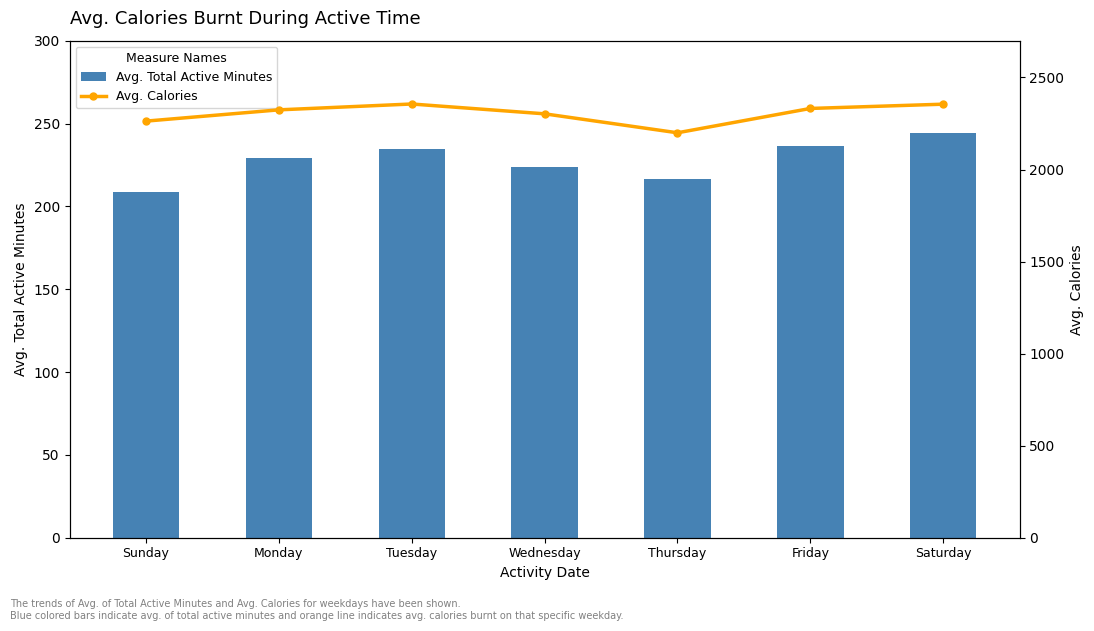

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ── STEP 1: Load & Prepare ────────────────────────────
df = pd.read_csv("dailyActivity_merged.csv")
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

# Total Active Minutes = Lightly + Fairly + Very
df['TotalActiveMinutes'] = (df['LightlyActiveMinutes'] +
                             df['FairlyActiveMinutes'] +
                             df['VeryActiveMinutes'])

# Average per weekday
weekly = df.groupby('Weekday').agg(
    AvgActiveMinutes=('TotalActiveMinutes', 'mean'),
    AvgCalories=('Calories', 'mean')
).reindex(day_order).round(1)

print(weekly)

# ── STEP 2: Plot Dual Axis Chart ──────────────────────
fig, ax1 = plt.subplots(figsize=(11, 6))

x = range(len(day_order))

# --- Blue Bars: Avg Total Active Minutes (left axis) ---
bars = ax1.bar(x, weekly['AvgActiveMinutes'],
               color='steelblue', width=0.5, label='Avg. Total Active Minutes')

ax1.set_ylabel('Avg. Total Active Minutes', fontsize=10)
ax1.set_ylim(0, 300)
ax1.set_xticks(x)
ax1.set_xticklabels(day_order, fontsize=9)
ax1.tick_params(axis='y')

# --- Orange Line: Avg Calories (right axis) ---
ax2 = ax1.twinx()
ax2.plot(x, weekly['AvgCalories'],
         color='orange', linewidth=2.5,
         marker='o', markersize=5,
         label='Avg. Calories')

ax2.set_ylabel('Avg. Calories', fontsize=10)
ax2.set_ylim(0, 2700)

# ── STEP 3: Formatting ────────────────────────────────
ax1.set_title('Avg. Calories Burnt During Active Time',
              fontsize=13, pad=12, loc='left')

# Shared x label
ax1.set_xlabel('Activity Date', fontsize=10)

# Legend — combine both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', title='Measure Names',
           fontsize=9, title_fontsize=9)

# Footer note
fig.text(0.01, -0.04,
         'The trends of Avg. of Total Active Minutes and Avg. Calories for weekdays have been shown.\n'
         'Blue colored bars indicate avg. of total active minutes and orange line indicates avg. calories burnt on that specific weekday.',
         fontsize=7, color='gray')

plt.tight_layout()
plt.show()

Weekday     Sunday  Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  \
Id                                                                           
1624580081  1822.0  1480.0   1399.0     1451.0    1362.0  1390.0    1538.0   
3977333714  1580.0  1645.0   1596.0     1221.0    1464.0  1521.0    1622.0   
2026352035  1404.0  1638.0   1431.0     1627.0    1548.0  1568.0    1572.0   
1844505072  1507.0  1464.0   1566.0     1491.0    1688.0  1690.0    1603.0   
2320127002  1700.0  1700.0   1869.0     1747.0    1537.0  1701.0    1820.0   
8253242879  2044.0  1869.0   1873.0     1958.0    1834.0  1712.0    1337.0   
1503960366  1769.0  1939.0   1968.0     1869.0    1482.0  1826.0    1895.0   
5553957443  1603.0  1996.0   2171.0     1720.0    1857.0  2111.0    1641.0   
2873212765  1816.0  1895.0   1938.0     1981.0    1820.0  1998.0    1974.0   
3372868164  1707.0  2012.0   1943.0     2018.0    2054.0  1874.0    1950.0   
4057192912     NaN     NaN   2286.0     2306.0    1776.0  1527.0

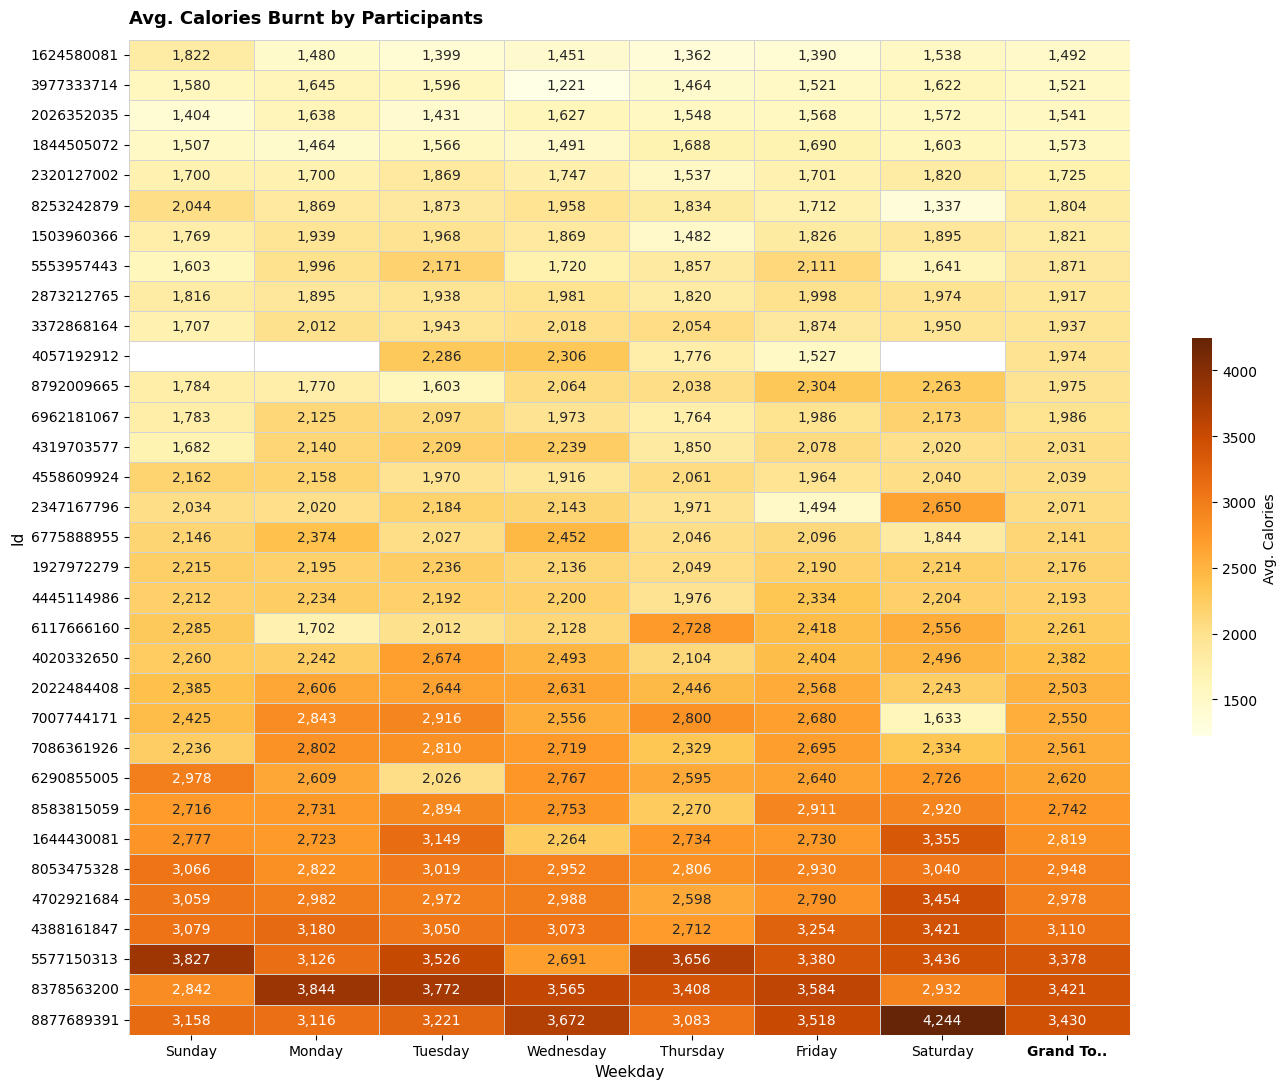

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── STEP 1: Load & Prepare ────────────────────────────
df = pd.read_csv("dailyActivity_merged.csv")
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

# Pivot — avg calories per participant per weekday
pivot_cal = df.pivot_table(index='Id',
                            columns='Weekday',
                            values='Calories',
                            aggfunc='mean')

# Reorder columns Sun → Sat
pivot_cal = pivot_cal[day_order]
pivot_cal.columns.name = 'Weekday'

# Add Grand Total column (avg across all days)
pivot_cal['Grand To..'] = pivot_cal.mean(axis=1)

# Sort rows by Grand Total low → high
pivot_cal = pivot_cal.sort_values('Grand To..')

# Round to whole numbers
pivot_cal = pivot_cal.round(0)

print(pivot_cal)

# ── STEP 2: Plot Heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

# Separate data columns and grand total for coloring
data_cols = day_order + ['Grand To..']

sns.heatmap(pivot_cal[data_cols],
            cmap='YlOrBr',           # yellow → orange → brown (matches screenshot)
            annot=True,
            fmt=',.0f',              # comma-formatted like 1,822
            linewidths=0.4,
            linecolor='lightgray',
            cbar_kws={'label': 'Avg. Calories',
                      'orientation': 'vertical',
                      'shrink': 0.4},
            ax=ax)

# Bold the Grand Total column header
ax.set_title('Avg. Calories Burnt by Participants',
             fontsize=13, pad=12, loc='left', fontweight='bold')

ax.set_xlabel('Weekday', fontsize=11)
ax.set_ylabel('Id', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

# Make Grand Total column label bold
labels = ax.get_xticklabels()
for label in labels:
    if 'Grand' in label.get_text():
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

Activity Date  Sunday  Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  \
Id                                                                              
6962181067      696.2   647.0    683.0      655.2     581.8   714.5     675.2   
5553957443      616.5   686.2    758.4      653.8     627.0   735.0     593.0   
2347167796      546.0   665.5    781.3      770.0     743.3   501.0     779.5   
2026352035      770.8   785.5    898.4      594.2     567.4   600.5     611.2   
3977333714      659.8   814.5    716.4      635.6     749.2   698.8     694.2   
8378563200      655.8   746.5    743.0      712.4     656.8   774.0     733.5   
4319703577      873.5   610.8    783.4      853.0     672.6   694.2     637.8   
5577150313      722.2   799.2    687.8      642.0     794.2   890.2     790.0   
4702921684      859.5   874.2    734.0      753.6     679.4   914.8     582.5   
6117666160      613.8   882.0   1095.5      930.8     814.0   621.5     616.5   
4388161847      615.0  1006.

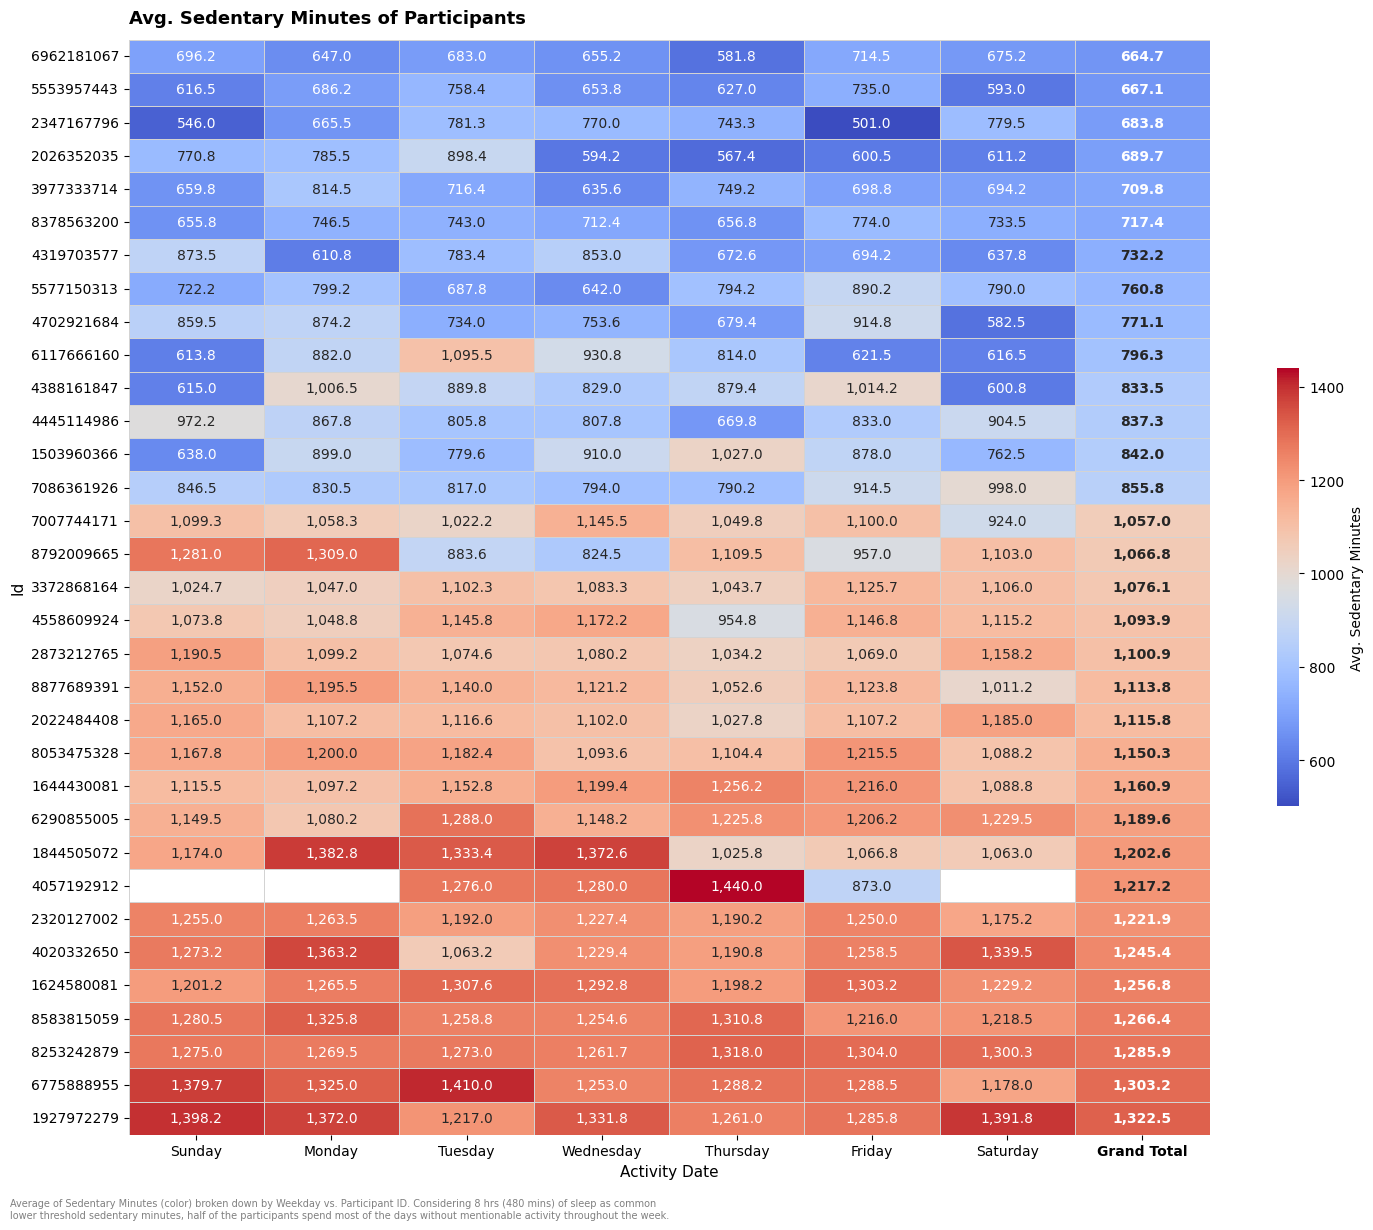

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── STEP 1: Load & Prepare ────────────────────────────
df = pd.read_csv("dailyActivity_merged.csv")
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

# Pivot — avg sedentary minutes per participant per weekday
pivot_sed = df.pivot_table(index='Id',
                            columns='Weekday',
                            values='SedentaryMinutes',
                            aggfunc='mean')

# Reorder columns Sun → Sat
pivot_sed = pivot_sed[day_order]
pivot_sed.columns.name = 'Activity Date'

# Add Grand Total column
pivot_sed['Grand Total'] = pivot_sed.mean(axis=1)

# Sort rows by Grand Total low → high
pivot_sed = pivot_sed.sort_values('Grand Total')

# Round to 1 decimal like screenshot
pivot_sed = pivot_sed.round(1)

print(pivot_sed)

# ── STEP 2: Plot Heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(pivot_sed,
            cmap='coolwarm',         # blue=low, red=high sedentary
            annot=True,
            fmt=',.1f',              # comma + 1 decimal like 1,356.5
            linewidths=0.4,
            linecolor='lightgray',
            cbar_kws={'label'      : 'Avg. Sedentary Minutes',
                      'orientation': 'vertical',
                      'shrink'     : 0.4},
            ax=ax)

# ── STEP 3: Formatting ────────────────────────────────
ax.set_title('Avg. Sedentary Minutes of Participants',
             fontsize=13, pad=12, loc='left', fontweight='bold')

ax.set_xlabel('Activity Date', fontsize=11)
ax.set_ylabel('Id', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

# Make Grand Total column label bold
for label in ax.get_xticklabels():
    if 'Grand' in label.get_text():
        label.set_fontweight('bold')

# Make Grand Total row values bold
for text in ax.texts:
    col = int(text.get_position()[0])
    if col == len(day_order):   # last column = Grand Total
        text.set_fontweight('bold')

# Footer note
fig.text(0.01, -0.02,
         'Average of Sedentary Minutes (color) broken down by Weekday vs. Participant ID. '
         'Considering 8 hrs (480 mins) of sleep as common\n'
         'lower threshold sedentary minutes, half of the participants spend most of the days '
         'without mentionable activity throughout the week.',
         fontsize=7, color='gray')

plt.tight_layout()
plt.show()

Hour
0      71.81
1      70.17
2      69.19
3      67.54
4      68.26
5      81.71
6      87.00
7      94.48
8     103.34
9     106.14
10    110.46
11    109.81
12    117.20
13    115.31
14    115.73
15    106.64
16    113.33
17    122.75
18    123.49
19    121.48
20    102.36
21     96.06
22     88.27
23     77.59
Name: Calories, dtype: float64


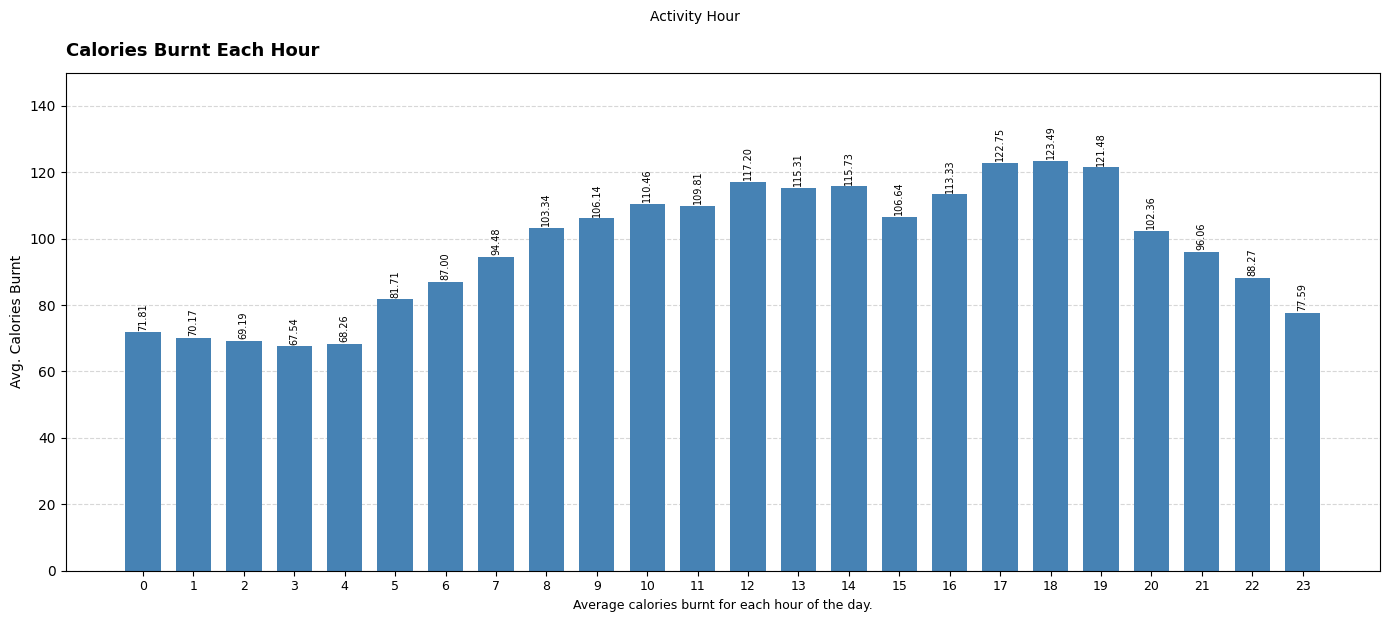

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ── STEP 1: Load & Prepare ────────────────────────────
df_hourly = pd.read_csv("hourlyCalories_merged.csv")

# Convert to datetime and extract hour
df_hourly['ActivityHour'] = pd.to_datetime(df_hourly['ActivityHour'],
                                            format='%m/%d/%Y %I:%M:%S %p')
df_hourly['Hour'] = df_hourly['ActivityHour'].dt.hour

# Average calories per hour (0–23)
avg_cal_hour = df_hourly.groupby('Hour')['Calories'].mean().round(2)

print(avg_cal_hour)

# ── STEP 2: Plot Bar Chart ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(avg_cal_hour.index,
              avg_cal_hour.values,
              color='steelblue',
              width=0.7)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_cal_hour.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}',
            ha='center', va='bottom',
            fontsize=7, rotation=90)

# ── STEP 3: Formatting ────────────────────────────────
ax.set_title('Calories Burnt Each Hour',
             fontsize=13, pad=12, loc='left', fontweight='bold')

ax.set_xlabel('Average calories burnt for each hour of the day.',
              fontsize=9)
ax.set_ylabel('Avg. Calories Burnt', fontsize=10)

# x-axis label above bars
ax.xaxis.set_label_position('bottom')
fig.text(0.5, 1.01, 'Activity Hour',
         ha='center', fontsize=10)

ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=9)
ax.set_ylim(0, 150)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()